In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("C:/Users/Cemo/Desktop/Panteon - Game Data Analyst - Marketing Train Data.csv")

In [5]:
# Basics
df.head()

,install_date,installs,revenue_d0,revenue_d1,revenue_d2,revenue_d3,revenue_d4,revenue_d5,revenue_d6,revenue_d7,...,retained_d19,retained_d20,retained_d21,retained_d22,retained_d23,retained_d24,retained_d25,retained_d26,retained_d27,retained_d28
0,2023-01-01,"6,466",3966.36,6160.06,7965.96,9190.79,10365.89,11607.31,13163.24,14065.54,...,867,865,873,816,770,763,685,681,674,678
1,2023-01-02,"9,152",3680.26,7374.64,8911.87,10192.94,11738.45,12768.99,13859.71,15493.33,...,877,853,848,820,764,730,726,704,693,704
2,2023-01-03,"10,954",2024.27,4061.54,5238.47,6289.57,7550.21,8158.14,8972.11,9742.11,...,683,648,619,613,611,595,590,525,518,510
3,2023-01-04,"7,180",2263.29,4365.42,5935.12,7424.63,8489.29,9623.41,10645.42,11313.86,...,713,688,664,629,609,608,592,567,560,546
4,2023-01-05,"7,792",2415.23,4856.27,6309.05,7150.53,7861.63,8345.74,8883.90,9602.54,...,624,609,601,538,527,502,490,473,448,440


In [6]:
df.describe()

,revenue_d0,revenue_d1,revenue_d2,revenue_d3,revenue_d4,revenue_d5,revenue_d6,revenue_d7,revenue_d8,revenue_d9,...,retained_d19,retained_d20,retained_d21,retained_d22,retained_d23,retained_d24,retained_d25,retained_d26,retained_d27,retained_d28
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,...,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,1671.020220,3061.419121,4015.441429,4826.086813,5522.715604,6172.563846,6770.167143,7369.198022,7894.086703,8354.492637,...,423.010989,412.219780,405.153846,384.747253,368.890110,356.175824,345.010989,333.494505,327.637363,321.219780
std,693.703427,1236.330114,1562.343390,1814.939318,2037.537492,2260.871671,2457.446387,2645.770920,2798.779900,2949.230599,...,146.638368,144.553012,141.103266,134.359269,129.250356,123.802674,119.648048,117.435881,116.129575,115.058806
min,746.890000,1397.250000,1925.120000,2276.080000,2649.550000,2941.270000,3271.280000,3576.850000,3839.150000,4113.190000,...,248.000000,230.000000,235.000000,217.000000,214.000000,207.000000,191.000000,192.000000,180.000000,188.000000
25%,1177.590000,2092.770000,2816.040000,3499.460000,4048.060000,4563.890000,5031.130000,5388.855000,5962.545000,6283.535000,...,323.500000,314.000000,314.000000,296.000000,285.500000,275.500000,272.500000,259.000000,255.500000,244.500000
50%,1495.800000,2707.430000,3601.320000,4381.720000,5054.190000,5616.900000,6138.840000,6662.440000,7143.400000,7499.390000,...,372.000000,361.000000,359.000000,341.000000,329.000000,315.000000,297.000000,291.000000,291.000000,284.000000
75%,2004.360000,3579.945000,4669.485000,5582.980000,6381.515000,7106.985000,7716.225000,8428.740000,9030.300000,9552.850000,...,453.500000,441.000000,434.000000,411.500000,384.000000,386.500000,369.500000,358.000000,350.000000,342.500000
max,4346.610000,7374.640000,8911.870000,10192.940000,11738.450000,12780.270000,13859.710000,15493.330000,16776.040000,17890.390000,...,877.000000,865.000000,873.000000,820.000000,770.000000,763.000000,726.000000,704.000000,693.000000,704.000000


In [7]:
df["installs"] = pd.to_numeric(df["installs"].str.replace(",", "", regex=False))

In [8]:
df["LTV_D28"] = df["revenue_d28"]

In [10]:
selected_features = [f"revenue_d{i}" for i in range(8)] + [f"retained_d{i}" for i in range(1, 8)]
selected_features.insert(0, "installs")

In [11]:
X = df[selected_features]
y = df["LTV_D28"]

In [53]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [54]:
polynomial_features = PolynomialFeatures(degree=2, include_bias=False)
scaler = StandardScaler()

In [55]:
pipeline = Pipeline([
    ("polynomial_features", polynomial_features),   
    ("scaler", scaler),                             
    ("model", GradientBoostingRegressor(random_state=42, n_estimators=180, learning_rate=0.095, max_depth=8))  
])

# Ton of adjustment for lr,ts,md,ne

In [56]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('polynomial_features', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.095, max_depth=6,
                                           n_estimators=180,
                                           random_state=42))])

In [57]:
y_pred = pipeline.predict(X_val)

In [58]:
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

In [59]:
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R^2 Score: {r2}")

Mean Absolute Error (MAE): 1349.81734207615
Mean Squared Error (MSE): 2586489.463326634
R^2 Score: 0.8904198619246124


C:\Users\Cemo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Cemo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


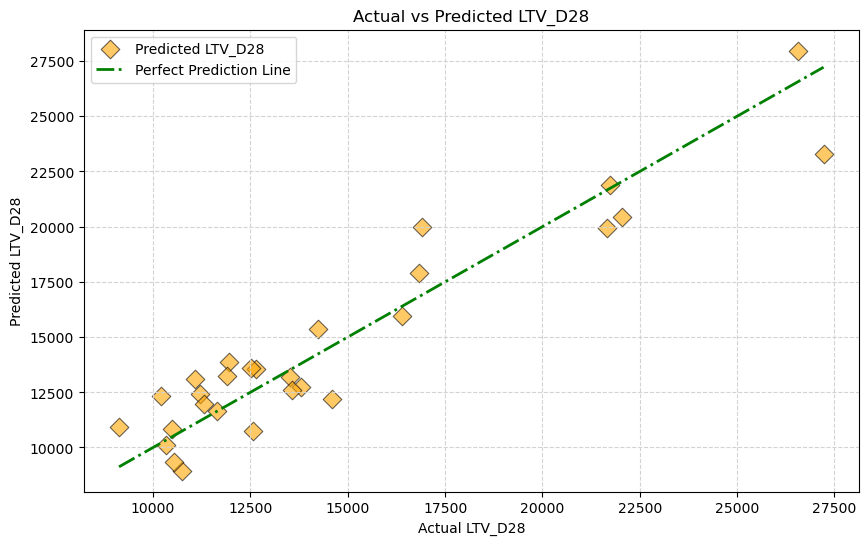

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred, marker="D", color="orange", alpha=0.6, edgecolor="black", s=90, label="Predicted LTV_D28")
sns.lineplot(x=[min(y_val), max(y_val)], y=[min(y_val), max(y_val)], color="green", linestyle='-.', linewidth=2, label="Perfect Prediction Line")
plt.title("Actual vs Predicted LTV_D28")
plt.xlabel("Actual LTV_D28")
plt.ylabel("Predicted LTV_D28")
plt.legend()
plt.grid(True, linestyle='--', color='lightgrey', linewidth=0.8)
plt.show()